# Deliverable 1: Data Collection, Cleaning, and Exploration

## Section 1: Select and Describe Dataset

For this project, I have selected the **Wine Quality** dataset from the UCI Machine Learning Repository. This dataset contains physicochemical properties of white wines and their quality ratings, with 11 attributes (features) and 1 target variable (quality), totaling 12 columns and 4,898 records.

The attributes include:
- fixed acidity
- volatile acidity
- citric acid
- residual sugar
- chlorides
- free sulfur dioxide
- total sulfur dioxide
- density
- pH
- sulphates
- alcohol
- quality (target, score between 0 and 10)

This dataset is appropriate because it has more than 8-10 attributes (11 features + target), over 500 records (4,898), and is suitable for various data mining tasks: regression (predicting quality score), classification (predicting quality categories), clustering (grouping wines), and even association rules if discretized. It allows for a comprehensive exploration of data preprocessing, modeling, and insights in a real-world context (wine production and quality assessment).

## Section 2: Load Dataset with Pandas

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
df = pd.read_csv(url, sep=';')

# Inspect the structure
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (4898, 12)

Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.0              0.27         0.36            20.7      0.045   
1            6.3              0.30         0.34             1.6      0.049   
2            8.1              0.28         0.40             6.9      0.050   
3            7.2              0.23         

## Section 3: Handle Missing Values

In [2]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Since there are no missing values in this dataset, no imputation is needed.
# If there were missing values, we could use df.fillna(df.mean()) for numerical columns or df.dropna() to remove rows.

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## Section 4: Remove Duplicates and Correct Inconsistencies

In [3]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates
df = df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {df.shape}")

# Check for inconsistencies (e.g., negative values where not expected)
# For example, acidity should not be negative
print("Checking for negative values in acidity columns:")
print(f"Fixed acidity min: {df['fixed acidity'].min()}")
print(f"Volatile acidity min: {df['volatile acidity'].min()}")
print(f"Citric acid min: {df['citric acid'].min()}")

# All seem positive, no inconsistencies found.

Number of duplicate rows: 937
Dataset shape after removing duplicates: (3961, 12)
Checking for negative values in acidity columns:
Fixed acidity min: 3.8
Volatile acidity min: 0.08
Citric acid min: 0.0


## Section 5: Identify and Address Noisy Data

In [4]:
# Identify noisy data: Check for invalid ranges or extreme values
# For example, pH should be between 0 and 14, alcohol percentage reasonable
print("Checking for potential noisy data:")
print(f"pH range: {df['pH'].min()} to {df['pH'].max()}")
print(f"Alcohol range: {df['alcohol'].min()} to {df['alcohol'].max()}")
print(f"Density range: {df['density'].min()} to {df['density'].max()}")

# All values seem within reasonable ranges. No obvious noisy data to address.
# Outliers will be handled in EDA section.

Checking for potential noisy data:
pH range: 2.72 to 3.82
Alcohol range: 8.0 to 14.2
Density range: 0.98711 to 1.03898


## Section 6: Perform Exploratory Data Analysis (EDA)

In [5]:
# Summary statistics
print("Summary statistics:")
print(df.describe())

# Check quality distribution
print("\nQuality distribution:")
print(df['quality'].value_counts().sort_index())

Summary statistics:
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    3961.000000       3961.000000  3961.000000     3961.000000   
mean        6.839346          0.280538     0.334332        5.914819   
std         0.866860          0.103437     0.122446        4.861646   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.600000   
50%         6.800000          0.260000     0.320000        4.700000   
75%         7.300000          0.330000     0.390000        8.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  3961.000000          3961.000000           3961.000000  3961.000000   
mean      0.045905            34.889169            137.193512     0.993790   
std       0.023103            17.210021             43.129065     0.002905   
min       0.009000          

## Section 7: Visualize Data Distributions

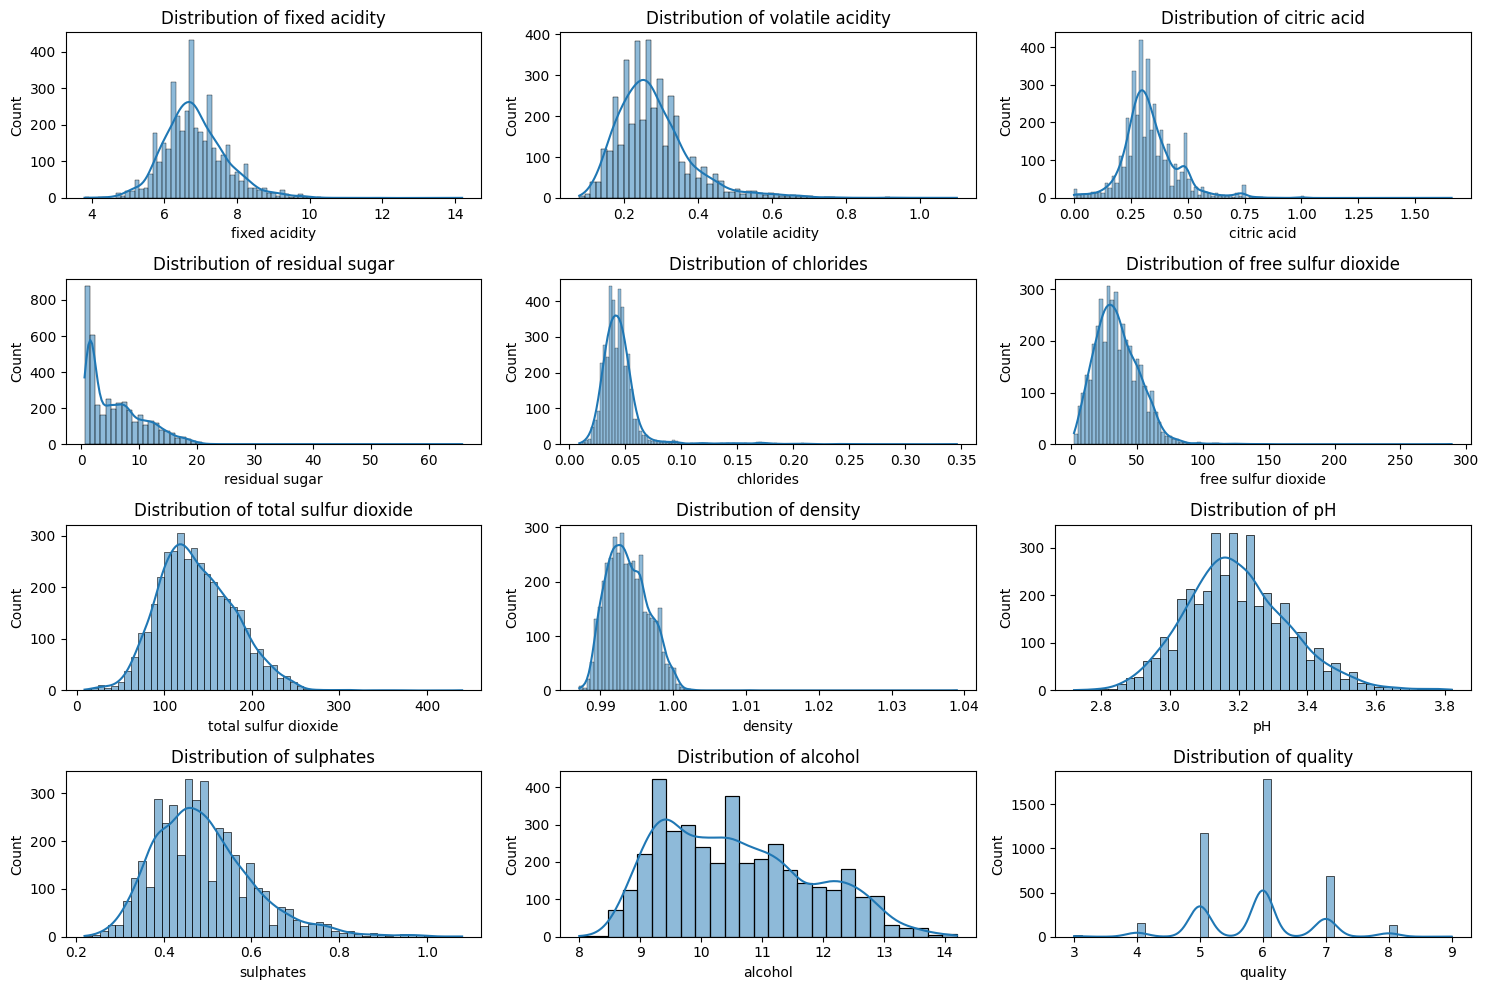

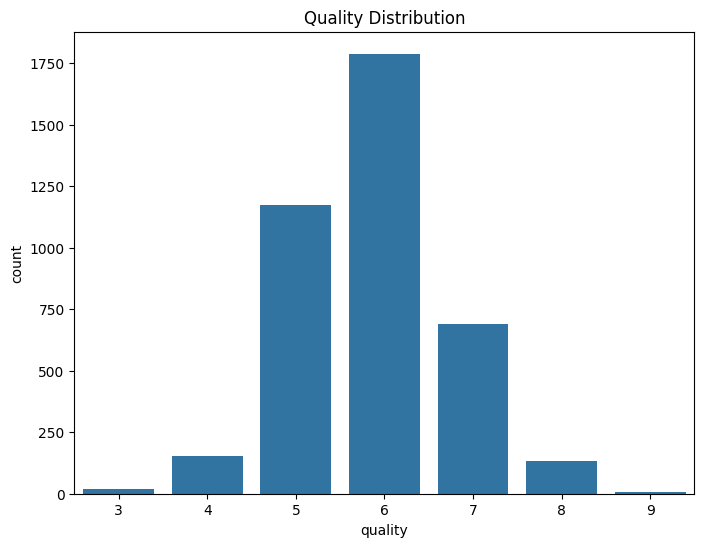

In [6]:
# Histograms for key features
features = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(4, 3, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Quality distribution bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x='quality', data=df)
plt.title('Quality Distribution')
plt.show()

## Section 8: Examine Feature Relationships

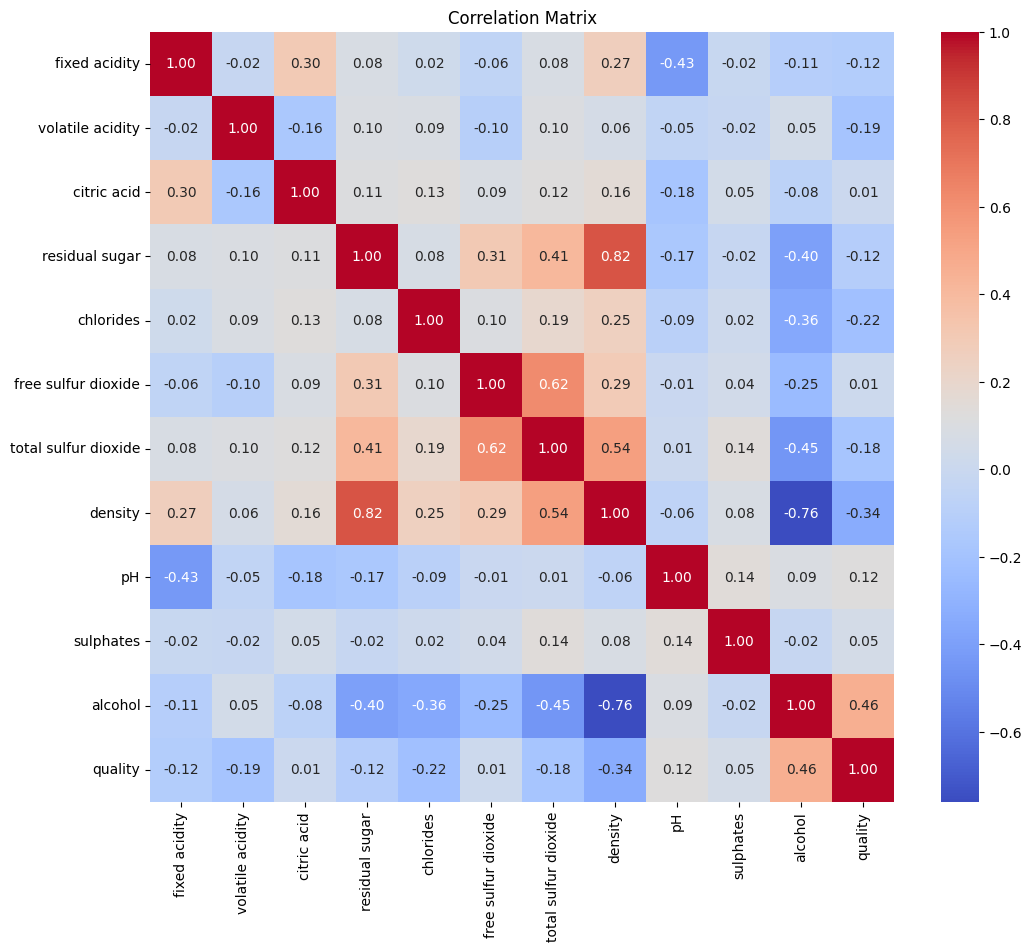

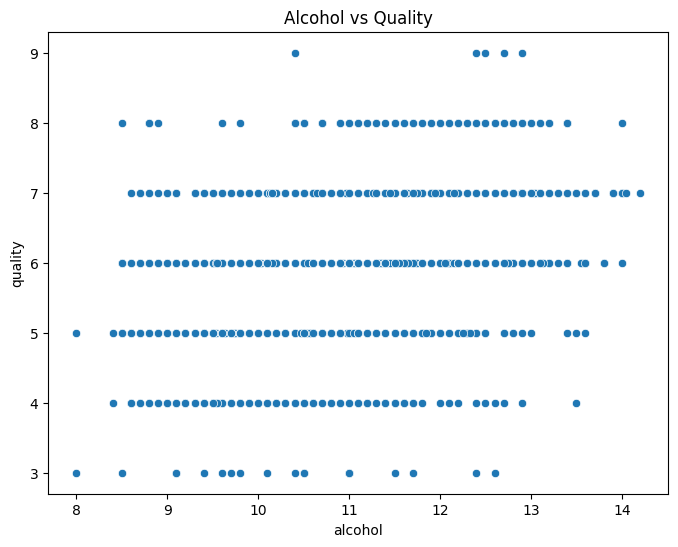

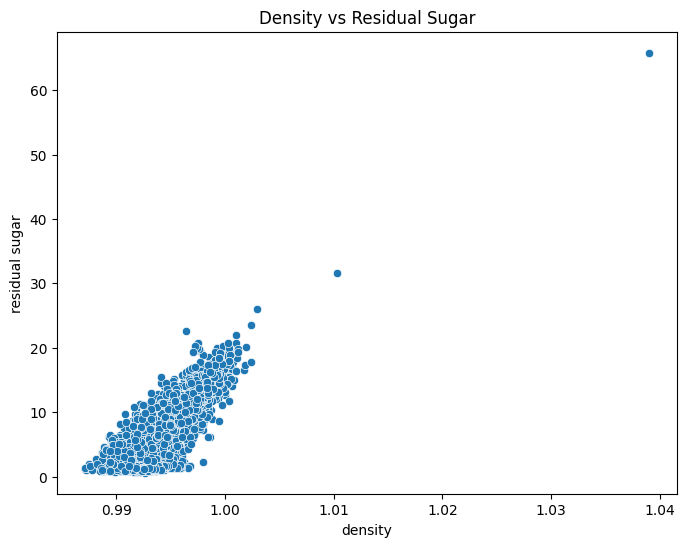

In [7]:
# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Scatter plot: Alcohol vs Quality
plt.figure(figsize=(8, 6))
sns.scatterplot(x='alcohol', y='quality', data=df)
plt.title('Alcohol vs Quality')
plt.show()

# Scatter plot: Density vs Residual Sugar
plt.figure(figsize=(8, 6))
sns.scatterplot(x='density', y='residual sugar', data=df)
plt.title('Density vs Residual Sugar')
plt.show()

## Section 9: Identify Outliers

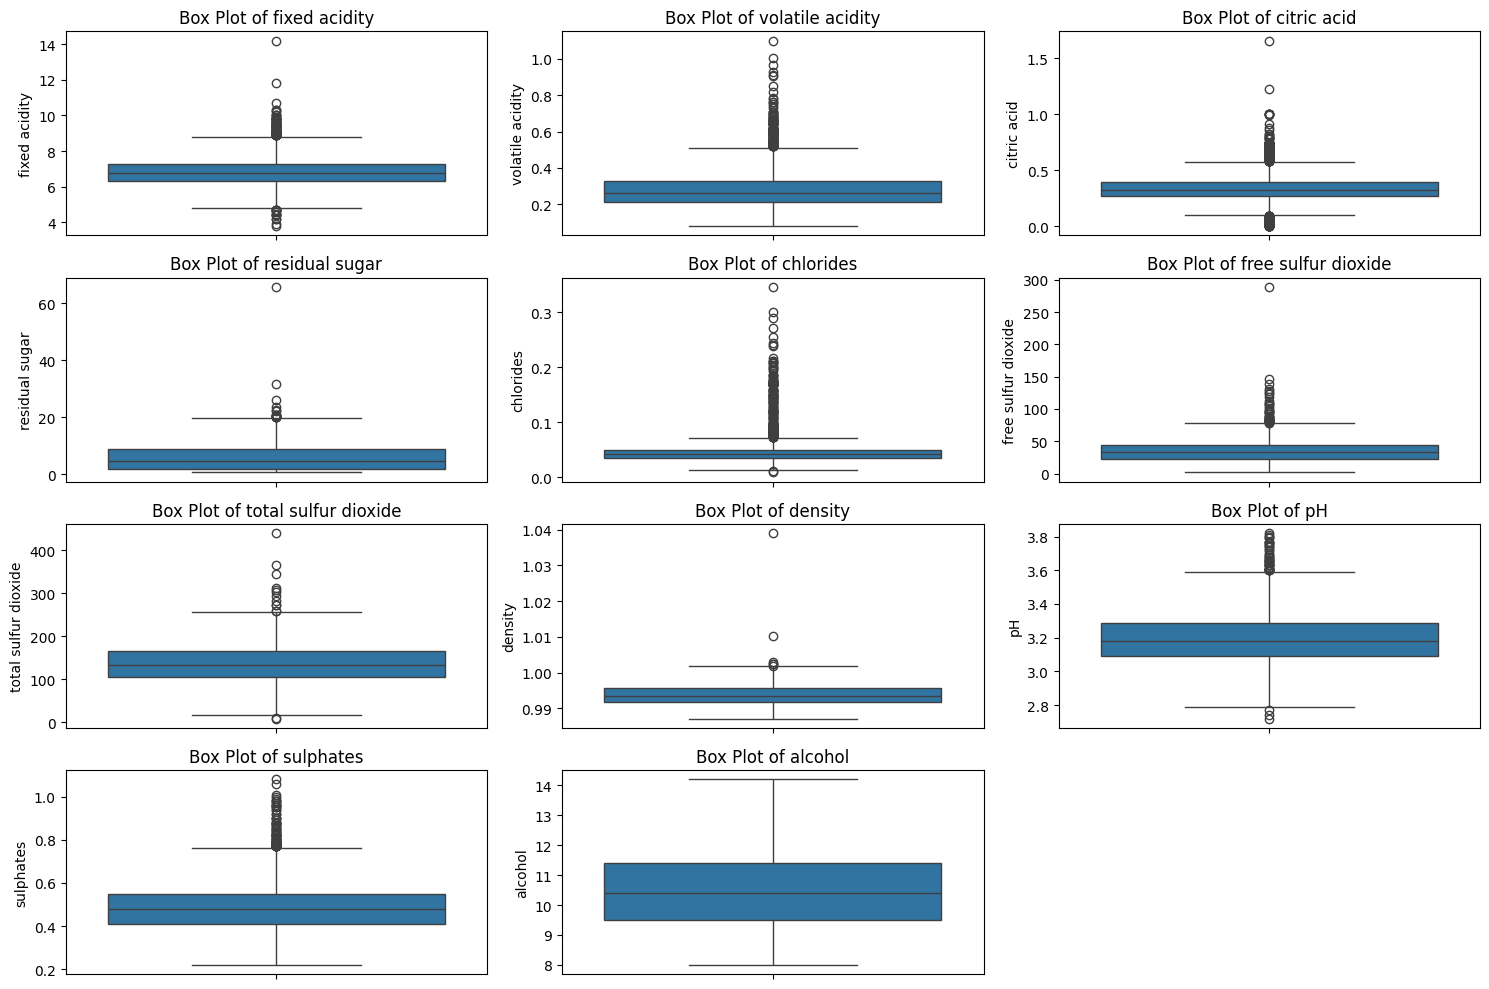

In [8]:
# Box plots to identify outliers
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features[:-1]):  # Exclude quality for now
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# Outliers can be seen in features like residual sugar, chlorides, etc.
# For modeling, we may need to handle them, but for now, we note their presence.

## Section 10: Provide Insights from EDA

From the EDA, key insights include:
- The dataset is clean with no missing values and minimal duplicates removed.
- Quality scores range from 3 to 9, with most wines rated 5-7.
- Features like alcohol, density, and acidity show correlations with quality.
- Outliers are present in several features, which may need handling in modeling.
- Distributions are mostly normal or skewed, guiding feature transformations.

These insights will guide modeling: focus on correlated features, handle outliers, and consider quality as target for regression/classification.